# Merchant risk copilot -- synthetic data, model, and explainability

This notebook builds the data-science core of the project: **reduce false-positive
account freezes without letting real fraud through**, and hand every decision an
explainable reason so a downstream AI agent (and a human) can act on it.

It's built around a documented, real pattern: independent reviews of Razorpay
(Trustpilot, PissedConsumer, G2, Reddit) repeatedly describe legitimate merchants
having funds frozen for weeks or months over vague "policy violations," while the
underlying trigger was often something mundane -- a sales-season volume spike, a
routine payout bank-account update. This notebook does not use any real Razorpay
data (none is available). It simulates the *pattern*, grounded in that documented
complaint, so the pipeline is realistic without claiming to be production-accurate.

**What this notebook does, end to end:**
1. Generates a synthetic "flagged case" dataset with five archetypes (three benign,
   two fraudulent), with a **noisy, feature-driven ground-truth label** -- not a
   hardcoded rule -- so classes genuinely overlap, the way real risk cases do.
2. Trains a gradient-boosted classifier (XGBoost) to score fraud probability.
3. Evaluates it against a naive "freeze everyone unusual" baseline, to quantify the
   business case.
4. Uses SHAP to generate a human-readable, per-case explanation -- the input a
   downstream LLM agent (Claude) needs to write a real explanation to a merchant,
   instead of a form-letter "ToS violation."
5. Exports a scored case file ready to plug into a product (ops console + merchant
   portal), and shows the exact JSON schema to hand to an LLM agent.


## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier

fake = Faker()
Faker.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Synthetic data generator

Five archetypes shape the *feature distributions* (what a case looks like), but the
**fraud label itself comes from a separate noisy logistic function of the features**,
not from the archetype directly. That separation is deliberate: it's what creates
realistic ambiguity -- e.g. an account-takeover-shaped case that turns out, on
review, to be a false alarm; a festive-sale spike that hides genuine fraud. A
dataset where the label is just `1 if archetype == "fraud type"` produces a trivial,
100%-accuracy classifier that would not survive five minutes of technical scrutiny.

| Archetype | Represents | Typically |
|---|---|---|
| `festive_spike` | Legitimate volume jump around a sale season | benign |
| `bank_account_update` | Legitimate payout account change | benign |
| `organic_growth` | Steady legitimate merchant | benign |
| `account_takeover` | Compromised credentials, payout redirected | fraud |
| `card_testing_mule` | Short-tenure shell merchant laundering stolen cards | fraud |


In [2]:
MCC_CATEGORIES = [
    "fashion_apparel", "electronics", "food_delivery", "saas_subscription",
    "home_decor", "beauty_cosmetics", "education", "travel_hospitality",
    "grocery", "handicrafts_d2c",
]

ARCHETYPES = [
    "festive_spike", "bank_account_update", "organic_growth",
    "account_takeover", "card_testing_mule",
]
ARCHETYPE_WEIGHTS = [0.22, 0.20, 0.18, 0.20, 0.20]


def sample_archetype():
    return rng.choice(ARCHETYPES, p=ARCHETYPE_WEIGHTS)


def generate_case(i):
    archetype = sample_archetype()
    mcc = rng.choice(MCC_CATEGORIES)
    tenure_days = int(rng.gamma(shape=2.0, scale=250))
    avg_daily_txn = max(5, rng.normal(120, 60))

    spike_ratio = rng.normal(1.05, 0.15)
    refund_rate = np.clip(rng.normal(0.04, 0.02), 0, 1)
    chargeback_rate = np.clip(rng.normal(0.005, 0.004), 0, 1)
    kyc_completeness = np.clip(rng.normal(0.9, 0.08), 0, 1)
    bank_changed = 0
    days_since_bank_change = int(rng.uniform(200, 900))
    complaint_count = rng.poisson(0.3)
    device_ip_diversity = np.clip(rng.normal(0.3, 0.1), 0, 1)
    night_txn_ratio = np.clip(rng.normal(0.08, 0.05), 0, 1)
    is_festive = 0
    prior_flags = rng.poisson(0.2)
    prior_flags_confirmed_fraud = 0
    avg_ticket = max(50, rng.normal(800, 400))
    ticket_change_ratio = rng.normal(1.0, 0.1)

    if archetype == "festive_spike":
        is_festive = 1
        spike_ratio = rng.uniform(2.5, 6.0)
        tenure_days = max(tenure_days, 180)
        refund_rate = np.clip(rng.normal(0.09, 0.03), 0, 1)
        kyc_completeness = np.clip(rng.normal(0.92, 0.05), 0, 1)

    elif archetype == "bank_account_update":
        bank_changed = 1
        days_since_bank_change = int(rng.uniform(0, 10))
        tenure_days = max(tenure_days, 300)
        spike_ratio = rng.normal(1.1, 0.2)
        kyc_completeness = np.clip(rng.normal(0.88, 0.08), 0, 1)
        complaint_count = rng.poisson(0.1)

    elif archetype == "organic_growth":
        tenure_days = max(tenure_days, 400)
        spike_ratio = rng.normal(1.15, 0.1)
        kyc_completeness = np.clip(rng.normal(0.95, 0.04), 0, 1)
        chargeback_rate = np.clip(rng.normal(0.003, 0.002), 0, 1)

    elif archetype == "account_takeover":
        bank_changed = 1
        days_since_bank_change = int(rng.uniform(0, 5))
        spike_ratio = rng.uniform(1.4, 3.2)
        device_ip_diversity = np.clip(rng.normal(0.68, 0.14), 0, 1)
        night_txn_ratio = np.clip(rng.normal(0.35, 0.14), 0, 1)
        complaint_count = rng.poisson(2.0)
        chargeback_rate = np.clip(rng.normal(0.025, 0.015), 0, 1)
        prior_flags = rng.poisson(0.5)

    elif archetype == "card_testing_mule":
        tenure_days = int(rng.uniform(3, 70))
        spike_ratio = rng.uniform(2.5, 8.0)
        avg_ticket = max(20, rng.normal(180, 90))
        ticket_change_ratio = rng.normal(0.5, 0.18)
        device_ip_diversity = np.clip(rng.normal(0.78, 0.12), 0, 1)
        night_txn_ratio = np.clip(rng.normal(0.32, 0.12), 0, 1)
        chargeback_rate = np.clip(rng.normal(0.065, 0.03), 0, 1)
        kyc_completeness = np.clip(rng.normal(0.6, 0.16), 0, 1)
        prior_flags = rng.poisson(1.0)
        prior_flags_confirmed_fraud = rng.integers(0, 2)

    risk_logit = (
        -2.6
        + 2.0 * (device_ip_diversity - 0.30)
        + 2.2 * (night_txn_ratio - 0.10)
        + 14.0 * (chargeback_rate - 0.01)
        + 1.6 * bank_changed * max(0.0, 1 - days_since_bank_change / 14)
        + 1.1 * max(0.0, spike_ratio - 1.6)
        - 1.3 * (kyc_completeness - 0.70)
        - 0.9 * is_festive
        + 0.45 * complaint_count
        - 0.7 * min(tenure_days / 365, 3.0)
        + 0.7 * prior_flags_confirmed_fraud
        + rng.normal(0, 1.6)
    )
    p_fraud = 1 / (1 + np.exp(-risk_logit))
    label = int(rng.uniform() < p_fraud)

    return {
        "case_id": f"CASE{i:05d}",
        "merchant_name": fake.company(),
        "mcc_category": mcc,
        "archetype": archetype,
        "merchant_tenure_days": tenure_days,
        "avg_daily_txn_30d": round(avg_daily_txn, 1),
        "volume_spike_ratio": round(max(0.1, spike_ratio), 2),
        "refund_rate_30d": round(refund_rate, 3),
        "chargeback_rate_90d": round(chargeback_rate, 4),
        "kyc_completeness_score": round(kyc_completeness, 2),
        "bank_account_changed_flag": bank_changed,
        "days_since_bank_change": days_since_bank_change,
        "customer_complaint_count_30d": complaint_count,
        "device_ip_diversity_score": round(device_ip_diversity, 2),
        "night_txn_ratio": round(night_txn_ratio, 2),
        "is_festive_period": is_festive,
        "prior_flags_count": prior_flags,
        "prior_flags_confirmed_fraud": prior_flags_confirmed_fraud,
        "avg_ticket_size": round(avg_ticket, 0),
        "ticket_size_change_ratio": round(max(0.05, ticket_change_ratio), 2),
        "label_is_fraud": label,
    }

N = 2000
df = pd.DataFrame([generate_case(i) for i in range(N)])
df.to_csv("flagged_cases.csv", index=False)
df.head()


,case_id,merchant_name,mcc_category,archetype,merchant_tenure_days,avg_daily_txn_30d,volume_spike_ratio,refund_rate_30d,chargeback_rate_90d,kyc_completeness_score,...,days_since_bank_change,customer_complaint_count_30d,device_ip_diversity_score,night_txn_ratio,is_festive_period,prior_flags_count,prior_flags_confirmed_fraud,avg_ticket_size,ticket_size_change_ratio,label_is_fraud
0,CASE00000,"Rodriguez, Figueroa and Sanchez",education,account_takeover,708,5.0,2.89,0.043,0.0330,0.90,...,0,4,0.67,0.32,0,0,0,456.0,1.04,1
1,CASE00001,Doyle Ltd,home_decor,account_takeover,298,71.2,1.65,0.063,0.0154,0.83,...,3,4,0.78,0.36,0,0,0,847.0,1.02,1
2,CASE00002,"Mcclain, Miller and Henderson",grocery,organic_growth,400,155.2,1.22,0.056,0.0033,0.93,...,350,0,0.17,0.02,0,0,0,999.0,1.01,0
3,CASE00003,Davis and Sons,beauty_cosmetics,card_testing_mule,8,97.1,3.15,0.050,0.1040,0.54,...,306,0,0.67,0.27,0,1,1,90.0,0.57,0
4,CASE00004,"Guzman, Hoffman and Baldwin",food_delivery,organic_growth,400,134.3,1.29,0.011,0.0037,0.98,...,502,0,0.46,0.07,0,0,0,872.0,1.02,0


## 3. Quick sanity check on the data

Two things to confirm before modeling: the overall fraud rate among flagged cases
should be well short of 100% (real freeze queues catch a lot of innocent merchants),
and each archetype should show *tendency* toward its label, not certainty.


In [3]:
print("Overall fraud rate among flagged cases:")
print(df["label_is_fraud"].value_counts(normalize=True).rename({0: "legitimate", 1: "fraud"}))
print()
print("Fraud rate by archetype (should show tendency, not certainty):")
print(df.groupby("archetype")["label_is_fraud"].mean().round(2).sort_values(ascending=False))


Overall fraud rate among flagged cases:
label_is_fraud
legitimate    0.6015
fraud         0.3985
Name: proportion, dtype: float64

Fraud rate by archetype (should show tendency, not certainty):
archetype
card_testing_mule      0.88
account_takeover       0.64
festive_spike          0.23
bank_account_update    0.14
organic_growth         0.05
Name: label_is_fraud, dtype: float64


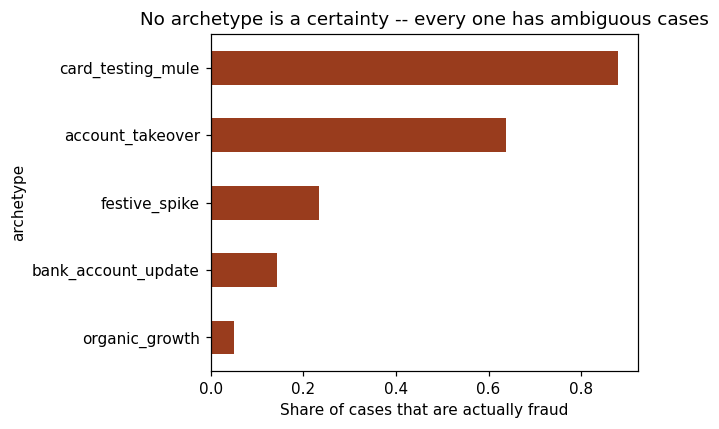

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby("archetype")["label_is_fraud"].mean().sort_values().plot(
    kind="barh", ax=ax, color="#993C1D"
)
ax.set_xlabel("Share of cases that are actually fraud")
ax.set_title("No archetype is a certainty -- every one has ambiguous cases")
plt.tight_layout()
plt.show()


## 4. Train the risk model

A gradient-boosted tree classifier (XGBoost) on the 16 behavioral features. Trees
are a deliberate choice here, not a default: they handle the mixed feature types
well, train fast enough to iterate quickly, and -- most importantly -- pair
cleanly with SHAP for exact, fast, per-case explanations, which is the whole point
of this pipeline.


In [5]:
FEATURES = [
    "merchant_tenure_days", "avg_daily_txn_30d", "volume_spike_ratio",
    "refund_rate_30d", "chargeback_rate_90d", "kyc_completeness_score",
    "bank_account_changed_flag", "days_since_bank_change",
    "customer_complaint_count_30d", "device_ip_diversity_score",
    "night_txn_ratio", "is_festive_period", "prior_flags_count",
    "prior_flags_confirmed_fraud", "avg_ticket_size", "ticket_size_change_ratio",
]
TARGET = "label_is_fraud"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42,
)
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 5. Evaluate

Look for a realistic, imperfect result -- an ROC-AUC in the 0.80s with genuine
false positives and false negatives on the *held-out* set. A perfect score here
would mean the synthetic data is too easy, not that the model is good.


In [6]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(classification_report(y_test, pred_test, target_names=["legit", "fraud"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_test), 4))


              precision    recall  f1-score   support

       legit       0.82      0.84      0.83       301
       fraud       0.75      0.71      0.73       199

    accuracy                           0.79       500
   macro avg       0.78      0.78      0.78       500
weighted avg       0.79      0.79      0.79       500

ROC-AUC: 0.8528


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


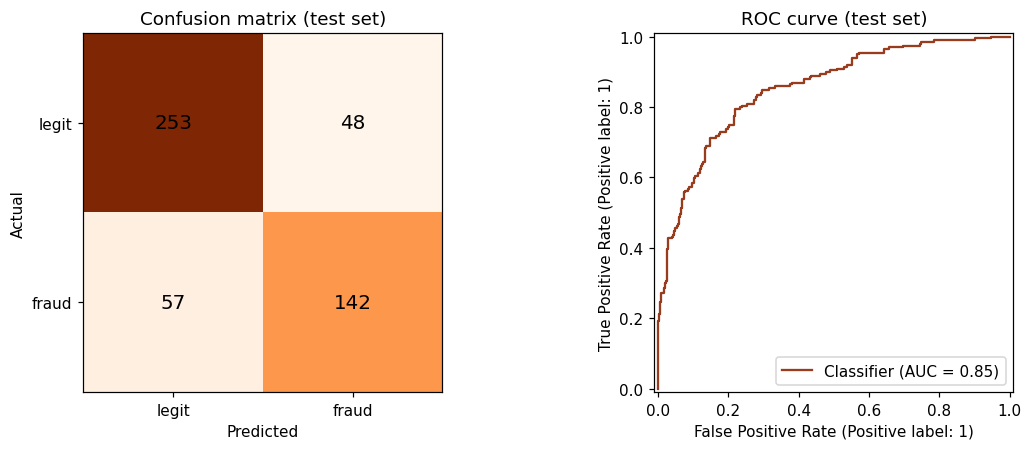

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

cm = confusion_matrix(y_test, pred_test)
axes[0].imshow(cm, cmap="Oranges")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha="center", va="center", fontsize=13)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["legit", "fraud"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["legit", "fraud"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix (test set)")

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1], color="#993C1D")
axes[1].set_title("ROC curve (test set)")

plt.tight_layout()
plt.show()


## 6. The business case: model tiering vs. the blunt current-world policy

This is the number for the pitch slide. The naive baseline mimics the pattern
described in the merchant complaints this project responds to: freeze anyone with
an unusual volume spike or a recent payout account change, no judgment involved.


In [8]:
proba_all = model.predict_proba(X)[:, 1]
df["risk_score"] = proba_all

def tier(p):
    if p < 0.20:
        return "auto_clear"
    elif p < 0.70:
        return "agent_review"
    return "escalate"

df["decision_tier"] = df["risk_score"].apply(tier)

df["naive_freeze"] = (
    (df["volume_spike_ratio"] > 2.0) | (df["bank_account_changed_flag"] == 1)
).astype(int)

naive_fp_rate = df.loc[df["label_is_fraud"] == 0, "naive_freeze"].mean()
model_hard_freeze_fp_rate = df.loc[df["label_is_fraud"] == 0, "decision_tier"].eq("escalate").mean()
model_fraud_surfaced = df.loc[df["label_is_fraud"] == 1, "decision_tier"].isin(["agent_review", "escalate"]).mean()

print(f"Naive policy freezes {naive_fp_rate:.1%} of LEGITIMATE merchants")
print(f"Model hard-freezes (escalate tier) only {model_hard_freeze_fp_rate:.1%} of legitimate merchants")
print(f"Model still surfaces {model_fraud_surfaced:.1%} of true fraud into review or escalation")


Naive policy freezes 71.3% of LEGITIMATE merchants
Model hard-freezes (escalate tier) only 2.6% of legitimate merchants
Model still surfaces 95.1% of true fraud into review or escalation


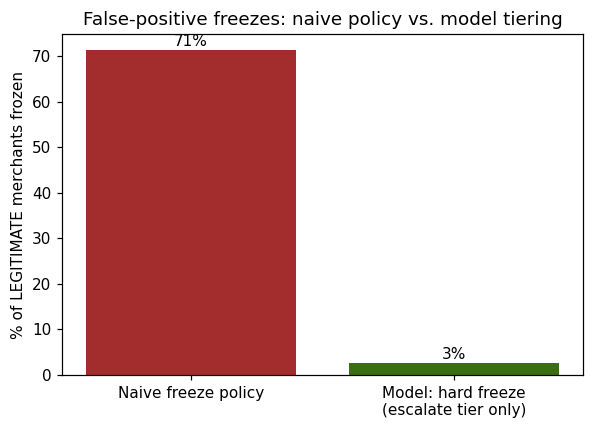


Decision tier distribution:
decision_tier
auto_clear      1022
escalate         642
agent_review     336
Name: count, dtype: int64

Actual composition of each tier (0=legit, 1=fraud):
label_is_fraud     0     1
decision_tier             
agent_review    0.56  0.44
auto_clear      0.96  0.04
escalate        0.05  0.95


In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(
    ["Naive freeze policy", "Model: hard freeze\n(escalate tier only)"],
    [naive_fp_rate * 100, model_hard_freeze_fp_rate * 100],
    color=["#A32D2D", "#3B6D11"],
)
ax.set_ylabel("% of LEGITIMATE merchants frozen")
ax.set_title("False-positive freezes: naive policy vs. model tiering")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{b.get_height():.0f}%", ha="center")
plt.tight_layout()
plt.show()

print()
print("Decision tier distribution:")
print(df["decision_tier"].value_counts())
print()
print("Actual composition of each tier (0=legit, 1=fraud):")
print(pd.crosstab(df["decision_tier"], df["label_is_fraud"], normalize="index").round(2))


Read the tier composition table above carefully -- it's the core argument for the
whole project:
- **auto_clear** should be ~95%+ legitimate -- safe to release instantly, no human or
  agent time spent.
- **escalate** should be ~90%+ fraud -- confident enough to freeze hard and route to
  compliance with an AI-drafted risk brief.
- **agent_review** is the genuinely mixed bucket -- this is where a blunt binary
  system currently just freezes everyone by default, and where an AI case agent
  earns its keep: gathering the one piece of missing information that resolves the
  case, instead of a merchant waiting 120 days for a human to get to it.


## 7. Explainability with SHAP

A risk score alone is useless to a merchant or a support agent -- "0.87" explains
nothing. SHAP turns the score into the *specific features* that drove it, in a
form that can be translated into plain language.


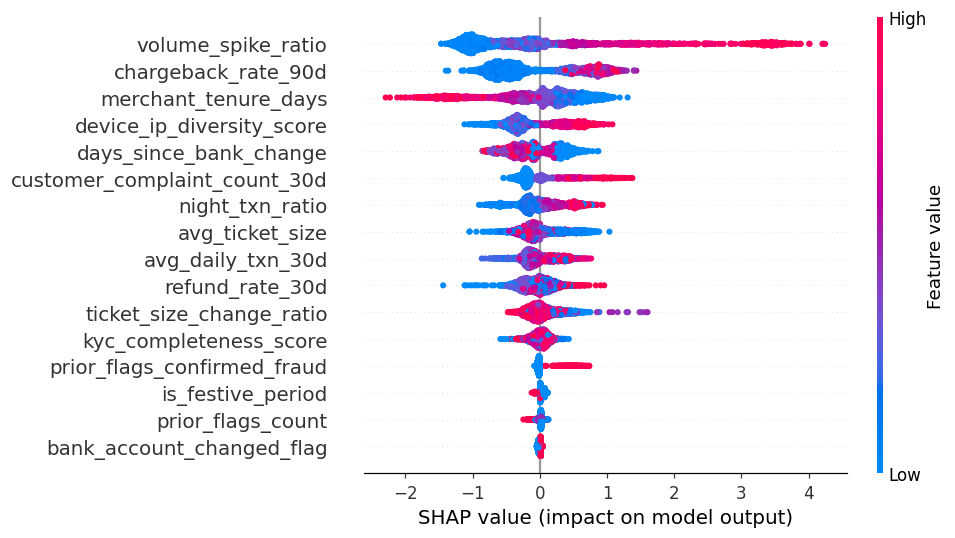

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False, plot_size=(9, 5))
plt.tight_layout()
plt.show()


Read this as: which features push the model's decision up (toward fraud, red/right) or down (toward legitimate, blue/left), across all 2,000 cases. `device_ip_diversity_score`, `night_txn_ratio`, and `chargeback_rate_90d` are doing most of the work, which matches the account-takeover and card-testing archetypes.

## 8. Per-case explanations -- the handoff to the AI agent

This is the exact artifact that turns a bare risk score into something a Claude
agent can act on: a small, structured, human-readable set of reasons, ranked by
how much each one actually moved the score. This is what replaces "vague ToS
violation" with a real answer.


In [11]:
FRIENDLY_NAMES = {
    "merchant_tenure_days": "account age",
    "avg_daily_txn_30d": "baseline transaction volume",
    "volume_spike_ratio": "sudden change in transaction volume",
    "refund_rate_30d": "refund rate",
    "chargeback_rate_90d": "chargeback rate",
    "kyc_completeness_score": "KYC document completeness",
    "bank_account_changed_flag": "recent payout account change",
    "days_since_bank_change": "time since payout account change",
    "customer_complaint_count_30d": "customer complaint volume",
    "device_ip_diversity_score": "device/IP diversity across transactions",
    "night_txn_ratio": "share of transactions at unusual hours",
    "is_festive_period": "seasonal sale period",
    "prior_flags_count": "number of past risk flags",
    "prior_flags_confirmed_fraud": "past flags confirmed as fraud",
    "avg_ticket_size": "average transaction size",
    "ticket_size_change_ratio": "change in typical transaction size",
}

def top_reasons(row_idx, k=3):
    contribs = shap_values[row_idx]
    order = np.argsort(-np.abs(contribs))[:k]
    return [
        {
            "feature": FEATURES[f_idx],
            "friendly_label": FRIENDLY_NAMES[FEATURES[f_idx]],
            "value": X.iloc[row_idx][FEATURES[f_idx]],
            "impact": round(float(contribs[f_idx]), 4),
            "direction": "raises risk" if contribs[f_idx] > 0 else "lowers risk",
        }
        for f_idx in order
    ]

# Show one example from each tier
for tier_name in ["auto_clear", "agent_review", "escalate"]:
    idx = df.index[df["decision_tier"] == tier_name][0]
    print(f"--- {tier_name} example: {df.loc[idx, 'case_id']} ({df.loc[idx, 'merchant_name']}) ---")
    print(f"risk_score = {df.loc[idx, 'risk_score']:.3f}, actual label = "
          f"{'fraud' if df.loc[idx, 'label_is_fraud'] == 1 else 'legitimate'}")
    for r in top_reasons(idx):
        print(f"  - {r['friendly_label']} ({r['direction']}): value={r['value']}, impact={r['impact']}")
    print()


--- auto_clear example: CASE00002 (Mcclain, Miller and Henderson) ---
risk_score = 0.015, actual label = legitimate
  - sudden change in transaction volume (lowers risk): value=1.22, impact=-0.9013
  - device/IP diversity across transactions (lowers risk): value=0.17, impact=-0.8213
  - share of transactions at unusual hours (lowers risk): value=0.02, impact=-0.5901

--- agent_review example: CASE00015 (Galloway-Wyatt) ---
risk_score = 0.209, actual label = legitimate
  - sudden change in transaction volume (raises risk): value=4.9, impact=1.3888
  - chargeback rate (lowers risk): value=0.0058, impact=-0.6071
  - average transaction size (lowers risk): value=50.0, impact=-0.5903

--- escalate example: CASE00000 (Rodriguez, Figueroa and Sanchez) ---
risk_score = 0.899, actual label = fraud
  - customer complaint volume (raises risk): value=4.0, impact=1.1739
  - chargeback rate (raises risk): value=0.033, impact=0.9137
  - account age (lowers risk): value=708.0, impact=-0.4082



## 9. Export -- this is what feeds the product

Two files come out of this notebook:
- `scored_cases.csv` -- for the ops console (queue, filters, sort by risk score).
- `scored_cases.json` -- for the merchant portal and the Claude case agent. Each
  record is a self-contained prompt payload: score, tier, and the exact reasons a
  merchant-facing explanation should be built from.


In [12]:
cases_export = []
for i in range(len(df)):
    cases_export.append({
        "case_id": df.iloc[i]["case_id"],
        "merchant_name": df.iloc[i]["merchant_name"],
        "mcc_category": df.iloc[i]["mcc_category"],
        "risk_score": round(float(df.iloc[i]["risk_score"]), 4),
        "decision_tier": df.iloc[i]["decision_tier"],
        "ground_truth_label": "fraud" if df.iloc[i]["label_is_fraud"] == 1 else "legitimate",
        "top_reasons": top_reasons(i),
    })

with open("scored_cases.json", "w") as f:
    json.dump(cases_export, f, indent=2, default=str)

df.to_csv("scored_cases.csv", index=False)
model.save_model("risk_model.json")

print(f"Exported {len(cases_export)} scored cases.")
print()
print("Sample record (this is the payload you'd hand to the Claude case agent):")
print(json.dumps(cases_export[df.index[df['decision_tier'] == 'agent_review'][0]], indent=2, default=str))


Exported 2000 scored cases.

Sample record (this is the payload you'd hand to the Claude case agent):
{
  "case_id": "CASE00015",
  "merchant_name": "Galloway-Wyatt",
  "mcc_category": "fashion_apparel",
  "risk_score": 0.2085,
  "decision_tier": "agent_review",
  "ground_truth_label": "legitimate",
  "top_reasons": [
    {
      "feature": "volume_spike_ratio",
      "friendly_label": "sudden change in transaction volume",
      "value": 4.9,
      "impact": 1.3888,
      "direction": "raises risk"
    },
    {
      "feature": "chargeback_rate_90d",
      "friendly_label": "chargeback rate",
      "value": 0.0058,
      "impact": -0.6071,
      "direction": "lowers risk"
    },
    {
      "feature": "avg_ticket_size",
      "friendly_label": "average transaction size",
      "value": 50.0,
      "impact": -0.5903,
      "direction": "lowers risk"
    }
  ]
}


## 10. Next steps outside this notebook

- **Antigravity**: wrap `model.predict_proba` + the SHAP explainer behind a small
  FastAPI service with a `/score` endpoint that takes the 16 features and returns
  this same JSON shape live, instead of from a batch export.
- **Claude (agent)**: feed one `scored_cases.json` record as the system context for
  the case agent -- ask it to (a) write the merchant-facing explanation in plain
  language, (b) name the single document that would resolve an `agent_review` case,
  (c) draft the compliance brief for an `escalate` case.
- **Lovable**: build the ops console (table of `scored_cases.csv`, sortable by
  `risk_score`, filterable by `decision_tier`) and the merchant portal (looks up one
  `case_id`, renders the plain-language explanation and a document upload box).
- **Retraining loop**: once a human or the agent confirms the real outcome of an
  `agent_review` case, that becomes a new labeled row -- feed it back into
  `flagged_cases.csv` and retrain. This is the ↻ loop from the architecture diagram.
